## PCA

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [3]:
np.random.seed(42)
data = np.random.rand(20, 5) * 10


col_names = ['Feature 1', 'Feature 2', 'Feature 3', 'Feature 4','Feature 5']
df = pd.DataFrame(data, columns=col_names)
df

,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5
0,3.745401,9.507143,7.319939,5.986585,1.560186
1,1.559945,0.580836,8.661761,6.011150,7.080726
2,0.205845,9.699099,8.324426,2.123391,1.818250
3,1.834045,3.042422,5.247564,4.319450,2.912291
4,6.118529,1.394939,2.921446,3.663618,4.560700
5,7.851760,1.996738,5.142344,5.924146,0.464504
6,6.075449,1.705241,0.650516,9.488855,9.656320
7,8.083973,3.046138,0.976721,6.842330,4.401525
8,1.220382,4.951769,0.343885,9.093204,2.587800
9,6.625223,3.117111,5.200680,5.467103,1.848545


### Step 1 as standardizing data


PCA is affected by scale because it relies on variance, which in turn
depends on the magnitude of the values. If one feature has much larger
values than another, it will dominate the principal components. 

In [4]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)
df_scaled = pd.DataFrame(data_scaled, columns=col_names)
df_scaled

,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5
0,-0.513409,1.770068,0.830464,0.333810,-0.945782
1,-1.269747,-1.305279,1.262529,0.342017,1.045325
2,-1.738371,1.836202,1.153907,-0.956774,-0.852705
3,-1.174887,-0.457198,0.163162,-0.223133,-0.458115
4,0.307878,-1.024799,-0.585844,-0.442228,0.136421
5,0.907711,-0.817463,0.129282,0.312951,-1.340964
6,0.292969,-0.917892,-1.317080,1.503821,1.974271
7,0.988075,-0.455918,-1.212043,0.619691,0.079011
8,-1.387262,0.200622,-1.415815,1.371645,-0.575150
9,0.483234,-0.431465,0.148066,0.160266,-0.841779


As this is a scaler, the results will now be within a magnitude of the mean
value and will have zero mean and unit variance.

### Step 2 as computing the covariance matrix


In [5]:
cov_matrix = np.cov(data_scaled.T)
df_cov_mat = pd.DataFrame(cov_matrix, columns=col_names, index=col_names)
cov_matrix ,' ', df_cov_mat


(array([[ 1.05263158, -0.26370208, -0.40067891, -0.07270115, -0.0089715 ],
        [-0.26370208,  1.05263158,  0.29949994,  0.05289981, -0.36700913],
        [-0.40067891,  0.29949994,  1.05263158, -0.14160599,  0.08135276],
        [-0.07270115,  0.05289981, -0.14160599,  1.05263158,  0.30162898],
        [-0.0089715 , -0.36700913,  0.08135276,  0.30162898,  1.05263158]]),
 ' ',
            Feature 1  Feature 2  Feature 3  Feature 4  Feature 5
 Feature 1   1.052632  -0.263702  -0.400679  -0.072701  -0.008971
 Feature 2  -0.263702   1.052632   0.299500   0.052900  -0.367009
 Feature 3  -0.400679   0.299500   1.052632  -0.141606   0.081353
 Feature 4  -0.072701   0.052900  -0.141606   1.052632   0.301629
 Feature 5  -0.008971  -0.367009   0.081353   0.301629   1.052632)

### Step 3 as computing eigenvalues and vectors


In [6]:
eigenvals, eigenvecs = np.linalg.eig(cov_matrix)

sort_indices = np.argsort(eigenvals)[::-1]
eigenvals = eigenvals[sort_indices]
eigenvecs = eigenvecs[:, sort_indices]
eigenvals  , '...', eigenvecs


(array([1.74495114, 1.39398192, 1.04949865, 0.66726099, 0.4074652 ]),
 '...',
 array([[ 0.51447746,  0.37719228, -0.04769777,  0.75816622, -0.12628468],
        [-0.5771786 ,  0.1113012 , -0.47897283,  0.39282666,  0.52033562],
        [-0.54157669, -0.27958815,  0.43637703,  0.45379591, -0.48183972],
        [ 0.14233775, -0.54967614, -0.70486503,  0.06248675, -0.42054346],
        [ 0.29767845, -0.68192714,  0.28469341,  0.24705439,  0.55161282]]))

###  Step 4 as choosing the number of principal components


we will select three components
and visualize their projections:

In [7]:
top_eigenvecs = eigenvecs[:, :3]
top_eigenvecs

array([[ 0.51447746,  0.37719228, -0.04769777],
       [-0.5771786 ,  0.1113012 , -0.47897283],
       [-0.54157669, -0.27958815,  0.43637703],
       [ 0.14233775, -0.54967614, -0.70486503],
       [ 0.29767845, -0.68192714,  0.28469341]])

### Step 5 as projecting data onto principal components


In [8]:
data_pca = np.dot(data_scaled, top_eigenvecs)

df_pca = pd.DataFrame(data_pca,
                       columns=['PC1', 'PC2', 'PC3'])
df_pca


,PC1,PC2,PC3
0,-1.969568,0.232636,-0.965480
1,-0.223781,-1.878040,1.293217
2,-2.969116,0.333452,0.138601
3,-0.597064,-0.104612,0.373081
4,1.044832,0.315916,0.571066
5,0.514172,0.957669,-0.197689
6,2.195562,-1.796340,-0.647001
7,1.539627,0.266314,-0.771969
8,-0.038711,-0.466840,-1.778318
9,0.189689,0.578790,-0.104391


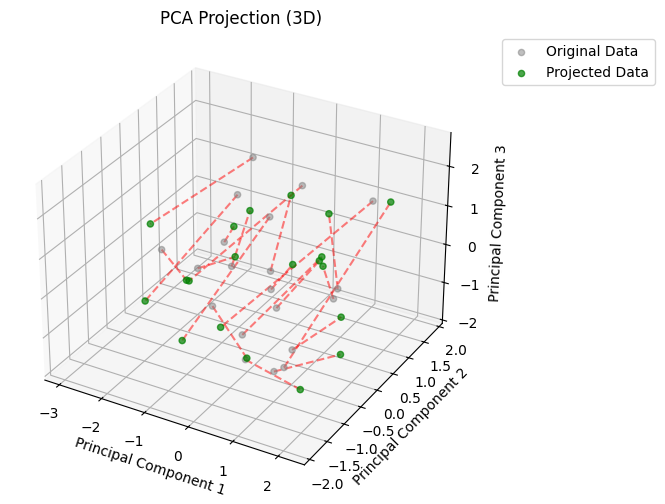

In [9]:

from modelviz.pca import plot_pca_projection

plot_pca_projection(
    df_original=df_scaled,
    df_projected=df_pca,
    labelpad=2,
    projected_color='green'
)


This 3D plot illustrates PCA, a technique used to reduce dimensionality by
transforming high-dimensional data (gray points) into a lower-dimensional
space (black points), while keeping as much important information
(variance) as possible.

## t-distributed Stochastic Neighbor Embedding


### Step 1 as computing similarities in high dimensional space

In [10]:
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
import pandas as pd
import matplotlib.pyplot as plt


In [11]:
np.random.seed(42)
X = np.random.rand(100, 50)

distances = euclidean_distances(X, X)
print(distances)

[[0.         2.8774868  3.08283448 ... 2.98328126 3.30388535 2.88351955]
 [2.8774868  0.         3.1558154  ... 3.11207808 3.25704102 3.086244  ]
 [3.08283448 3.1558154  0.         ... 2.94247323 2.94295433 2.75740803]
 ...
 [2.98328126 3.11207808 2.94247323 ... 0.         3.00268666 3.24210765]
 [3.30388535 3.25704102 2.94295433 ... 3.00268666 0.         2.83103515]
 [2.88351955 3.086244   2.75740803 ... 3.24210765 2.83103515 0.        ]]


In [12]:

def compute_p_ij(distances, sigma=1.0):
    P = np.exp(-distances ** 2 / (2 * sigma ** 2))  #  Gauss distrbution
    P /= np.sum(P, axis=1, keepdims=True) # normalization 
    
    return  (P + P.T) / (2 * len(P))  # for simmetic matrix


P = compute_p_ij(distances)
print("Shape of P:", P.shape)
# print(P)


Shape of P: (100, 100)


The P /= step
normalizes the values between 0 and 1, and the return statement
makes sure that the matrices maintain symmetry

### Step 2 as Student t-distribution and mapping to lower dimensions

In [13]:
np.random.seed(42)
Y = np.random.randn(100, 2)

In [14]:

distances_low = euclidean_distances(Y, Y)

#  t-distribution kernel
# this ensures that nearby points have higher similarity values,
#  while distant points have lower values
Q = (1 + distances_low ** 2) ** -1
print(Q)

[[1.         0.26436203 0.64793743 ... 0.72526229 0.33430999 0.45419012]
 [0.26436203 1.         0.205538   ... 0.39689672 0.19154782 0.11827261]
 [0.64793743 0.205538   1.         ... 0.64530913 0.63590888 0.52316205]
 ...
 [0.72526229 0.39689672 0.64530913 ... 1.         0.46062464 0.29860713]
 [0.33430999 0.19154782 0.63590888 ... 0.46062464 1.         0.28019778]
 [0.45419012 0.11827261 0.52316205 ... 0.29860713 0.28019778 1.        ]]


In [15]:
# diagonal of the  matrix to zero
np.fill_diagonal(Q, 0)
print(Q)

[[0.         0.26436203 0.64793743 ... 0.72526229 0.33430999 0.45419012]
 [0.26436203 0.         0.205538   ... 0.39689672 0.19154782 0.11827261]
 [0.64793743 0.205538   0.         ... 0.64530913 0.63590888 0.52316205]
 ...
 [0.72526229 0.39689672 0.64530913 ... 0.         0.46062464 0.29860713]
 [0.33430999 0.19154782 0.63590888 ... 0.46062464 0.         0.28019778]
 [0.45419012 0.11827261 0.52316205 ... 0.29860713 0.28019778 0.        ]]


In [16]:
# normalization
Q /= np.sum(Q)
print(Q)

[[0.00000000e+00 7.57844371e-05 1.85743671e-04 ... 2.07910323e-04
  9.58363618e-05 1.30202296e-04]
 [7.57844371e-05 0.00000000e+00 5.89214038e-05 ... 1.13778045e-04
  5.49108494e-05 3.39051073e-05]
 [1.85743671e-04 5.89214038e-05 0.00000000e+00 ... 1.84990218e-04
  1.82295457e-04 1.49974419e-04]
 ...
 [2.07910323e-04 1.13778045e-04 1.84990218e-04 ... 0.00000000e+00
  1.32046873e-04 8.56014525e-05]
 [9.58363618e-05 5.49108494e-05 1.82295457e-04 ... 1.32046873e-04
  0.00000000e+00 8.03240601e-05]
 [1.30202296e-04 3.39051073e-05 1.49974419e-04 ... 8.56014525e-05
  8.03240601e-05 0.00000000e+00]]


In [17]:
# combine Steps 1 to 4 into a function for later reuse:
def compute_q_dist(Y):
    
    distances_low = euclidean_distances(Y, Y)
    Q = (1 + distances_low ** 2) ** -1
    np.fill_diagonal(Q, 0)
    Q /= np.sum(Q)

    return Q


In [18]:
Q = compute_q_dist(Y)
print("Shape of Q:", Q.shape)


Shape of Q: (100, 100)


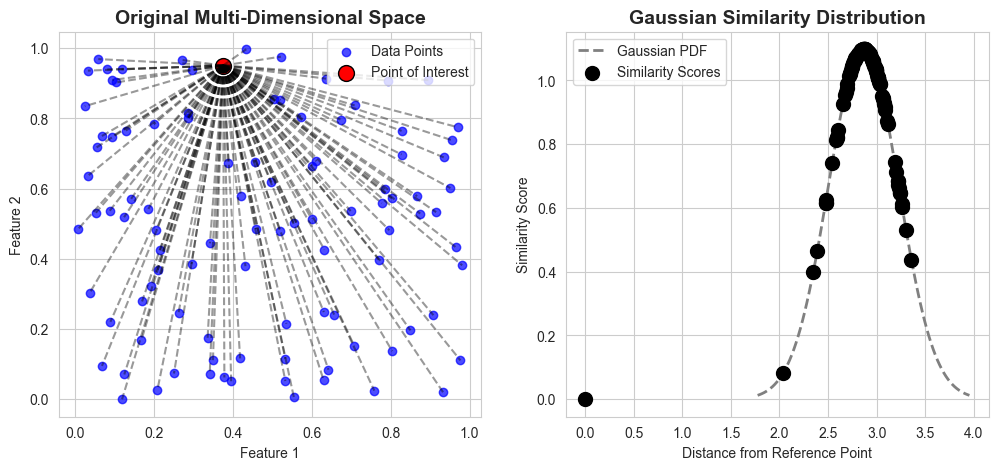

(array([0.        , 2.8774868 , 3.08283448, 2.85783193, 3.00714246,
        3.06627829, 3.22489426, 2.58750335, 2.92257248, 2.78584061,
        2.9907427 , 2.76128243, 2.58291471, 2.03537303, 2.8629311 ,
        2.77051999, 2.77475033, 2.94449273, 3.26246169, 2.8720773 ,
        3.01659095, 2.67999499, 2.96037056, 2.87531439, 3.03074716,
        2.89446294, 2.58820817, 2.87650418, 3.3577245 , 2.99289449,
        3.06439214, 2.79571928, 2.47414326, 3.23936302, 2.9963947 ,
        3.21795827, 2.67206835, 3.01613447, 2.6988154 , 3.1847456 ,
        2.83736684, 2.47383288, 3.02510885, 2.47876526, 3.01477081,
        2.80603788, 2.74701557, 3.01315446, 3.05970464, 2.96738295,
        2.73015637, 3.03248475, 2.98908853, 2.83793536, 2.7946122 ,
        2.95922433, 2.65387788, 2.99400202, 2.96362646, 3.01664594,
        3.23046565, 2.95396796, 2.9773462 , 3.11056542, 2.74943937,
        2.92788135, 2.72032328, 3.07626019, 3.08880359, 2.6900119 ,
        3.23790484, 2.86843267, 2.91640847, 2.89

In [19]:
from modelviz.relationships import plot_similarity

plot_similarity(
    data =X,
    point_of_interest =X[0],
    std_range =3,
    similarity_color='black',
    curve_color   ='grey',
    seaborn_style ='whitegrid'
)


### Step 3 as Kullback-Leibler divergence


__KL loss function__

In [20]:
# small constant to each side of the P and Q distributions to avoid the division by zero error

def kl_divergence(P, Q):
    return np.sum(P * np.log((P + 1e-9) / (Q + 1e-9)))

loss = kl_divergence(P=P, Q=Q)
print(loss)


5.368230862751237


the predictions are off from the true reference of P

### Step 4 as gradient descent on our cost function


Y (the current 2D position of all points);

 P (the pairwise similarities from the high-dimensional space, computed in Step 1); 

Q (the pairwise similarities in low-dimensional space) 

In [21]:
def update_Y(Y, P, Q, learning_rate=0.1):
    gradients = np.zeros_like(Y) # represents the current positions of all points

    for i in range(Y.shape[0]):  # 100 
        diff = Y[i] - Y         #how far the current point is from every other point
        grad = 4 * np.sum(  (P[i, :, None] - Q[i, :, None]) * 
                          diff * 
                          (1 + np.sum(diff ** 2, axis=1, keepdims=True)) ** -1,# squared Euclidean distance.
                          axis=0)
        gradients[i] = grad
    Y -= learning_rate * gradients
    return Y


In [22]:
ITERATION = 601
losses = []
iters = []

for idx, _ in enumerate(range(ITERATION)):
    Q = compute_q_dist(Y)
    Y = update_Y(Y, P, Q)
    loss = kl_divergence(P, Q)

    if idx % 50 == 0:
        print(f"⌛ ITERATION: {idx + 1} Loss: {loss:.4f}")

    losses.append(loss)
    iters.append(idx + 1)


⌛ ITERATION: 1 Loss: 5.3682
⌛ ITERATION: 51 Loss: 5.3678
⌛ ITERATION: 101 Loss: 5.3674
⌛ ITERATION: 151 Loss: 5.3671
⌛ ITERATION: 201 Loss: 5.3668
⌛ ITERATION: 251 Loss: 5.3666
⌛ ITERATION: 301 Loss: 5.3664
⌛ ITERATION: 351 Loss: 5.3662
⌛ ITERATION: 401 Loss: 5.3661
⌛ ITERATION: 451 Loss: 5.3661
⌛ ITERATION: 501 Loss: 5.3660
⌛ ITERATION: 551 Loss: 5.3660
⌛ ITERATION: 601 Loss: 5.3660


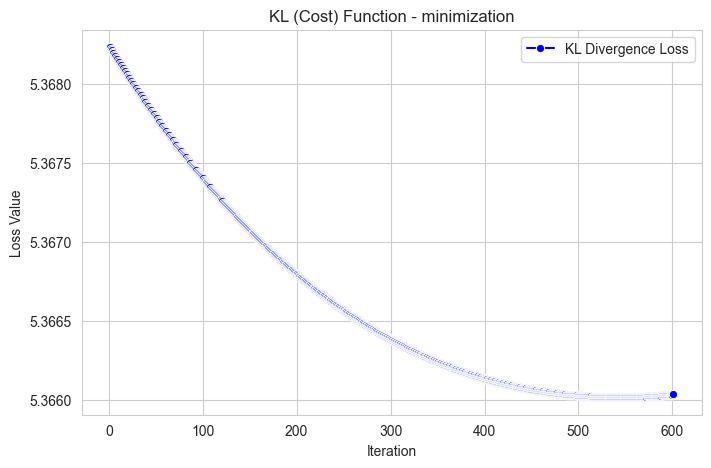

In [23]:
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.lineplot(x=iters, y=losses, marker='o',
             color='blue',
             label="KL Divergence Loss")

plt.xlabel("Iteration")
plt.ylabel("Loss Value")
plt.title("KL (Cost) Function - minimization")
plt.legend()
plt.grid(True)
plt.show()


## Uniform Manifold Approximation and Projection


In [ ]:
import numpy as np
import umap
from sklearn.metrics.pairwise import euclidean_distances

np.random.seed(42)
X = np.random.rand(100, 50)
distances = euclidean_distances(X, X)


c:\Users\USER\envs\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Exception ignored on calling ctypes callback function <function ExecutionEngine._raw_object_cache_notify at 0x000001EBC5B4E700>:
Traceback (most recent call last):
  File "c:\Users\USER\envs\env\Lib\site-packages\llvmlite\binding\executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):
KeyboardInterrupt: 


In [ ]:


umap_model = umap.UMAP(n_neighbors=15, # 15 nearest  neighbors
                       min_dist=0.1,
                       random_state=42)


In [ ]:
graph = umap_model.fit(X)
knn_graph = graph.graph_
print(f"Graph has {knn_graph.shape[0]} nodes and {knn_graph.shape[1]} edges")


Graph has 100 nodes and 100 edges


This will print the shape of (100, 2), which is the nodes and features tuple
we had previously, showing that the algorithm has effectively reduced it
down to two dimensions

In [ ]:
X_embed = umap_model.fit_transform(X)
print(f"New shape: {X_embed.shape}")


New shape: (100, 2)


## Visualizing high-dimensional data in 2D and 3D


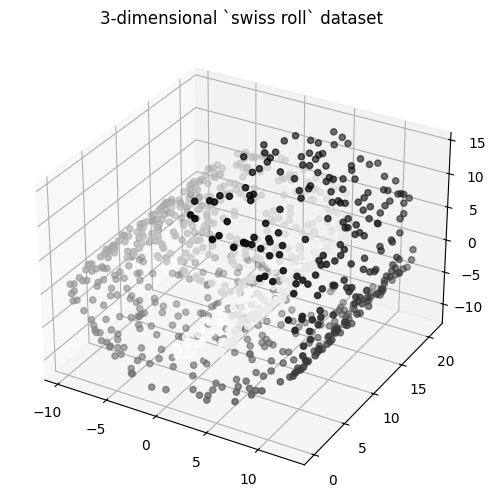

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll


X_swiss, color = make_swiss_roll(n_samples=1000,
                                 noise=0.1,
                                 random_state=42)


fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, 
                     projection='3d')

ax.scatter(X_swiss[:, 0],
           X_swiss[:, 1],
           X_swiss[:, 2],
           c=color,
           cmap='Greys')

ax.set_title("3-dimensional `swiss roll` dataset")
plt.show()


c:\Users\USER\envs\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


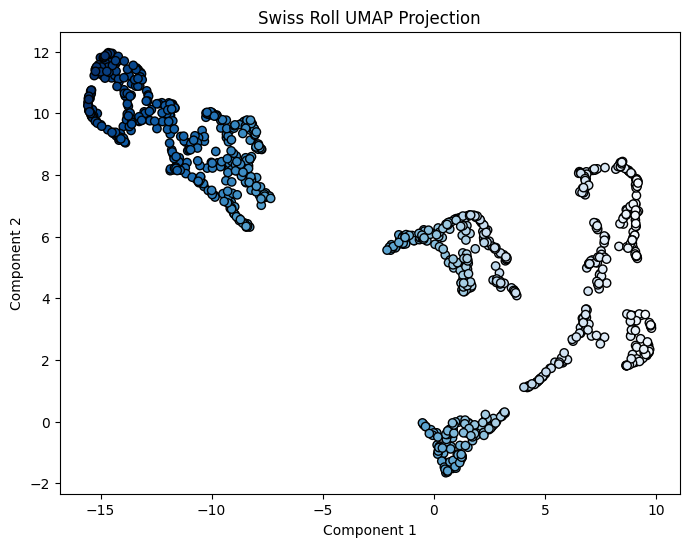

In [ ]:
import umap

def apply_umap(X, **kwargs):
    reducer = umap.UMAP(**kwargs)
    return reducer.fit_transform(X)


X_swiss_umap = apply_umap(X=X_swiss,
                          n_components=2,
                          random_state=42)



plt.figure(figsize=(8, 6))
plt.scatter(X_swiss_umap[:, 0],
            X_swiss_umap[:, 1],
            c=color,
            cmap='Blues',
            edgecolors='k')

plt.title("Swiss Roll UMAP Projection")
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.show()


##  MNIST dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn   as sns 

from  sklearn.decomposition  import PCA
from  sklearn.manifold import TSNE
import umap

from  sklearn.datasets  import fetch_openml
from  sklearn.utils import shuffle
from  sklearn.metrics  import confusion_matrix

c:\Users\USER\envs\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:


mnist = fetch_openml('mnist_784',version = 1)
len(mnist.data)

70000

In [5]:
X,y = mnist.data ,  mnist.target.astype(int)


In [6]:
X,y = shuffle(X, y,random_state=42)

In [7]:
class_labels  = np.unique(y)
class_labels

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [8]:
X.to_numpy()[0].shape

(784,)

Axes(0.125,0.11;0.065678x0.77)
Axes(0.203814,0.11;0.065678x0.77)
Axes(0.282627,0.11;0.065678x0.77)
Axes(0.361441,0.11;0.065678x0.77)
Axes(0.440254,0.11;0.065678x0.77)
Axes(0.519068,0.11;0.065678x0.77)
Axes(0.597881,0.11;0.065678x0.77)
Axes(0.676695,0.11;0.065678x0.77)
Axes(0.755508,0.11;0.065678x0.77)
Axes(0.834322,0.11;0.065678x0.77)


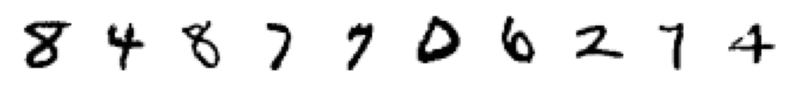

In [9]:
def plot_mnist_samples(X,y, num_samples=10, cmap = 'Greys', figsize=(10,3)):
    fig,axes =plt.subplots(1,
                           num_samples, 
                           figsize = figsize  
                           )
    for  i ,ax in  enumerate(axes):
        print(ax)
        ax.imshow(X[i].reshape(28,28),
                  cmap =cmap )
        ax.axis('off')
    plt.show()

plot_mnist_samples(X.to_numpy(), y)


## Creating our two-dimensional plotting function


In [10]:
def plot_2D(X_proj, y ,  title,  marker_size =5,  col_pal='tab10', # 
            alpha=0.7,   marker_scale =2,  **kwargs):
    
    plt.figure(figsize=(10,6))

    for key in  ['s','alpha','hue','palette']:
        kwargs.pop(key,None)

    sns.scatterplot(
                    x = X_proj[:,0],
                    y = X_proj[:,1],
                    hue = y,
                    palette= col_pal,
                    s=  marker_size,
                    alpha = alpha,
                    **kwargs  )
    plt.title(title)
    plt.legend(loc = 'best',
               markerscale=marker_scale)
    plt.show()

## Splitting and scaling the MNIST dataset


In [11]:
from  sklearn.model_selection import train_test_split
from  sklearn.preprocessing  import  StandardScaler

X_train ,X_test , y_train ,y_test = train_test_split(X,
                                                     y,
                                                     test_size=0.8 ,
                                                     random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## PCA for visualization in two-dimensions


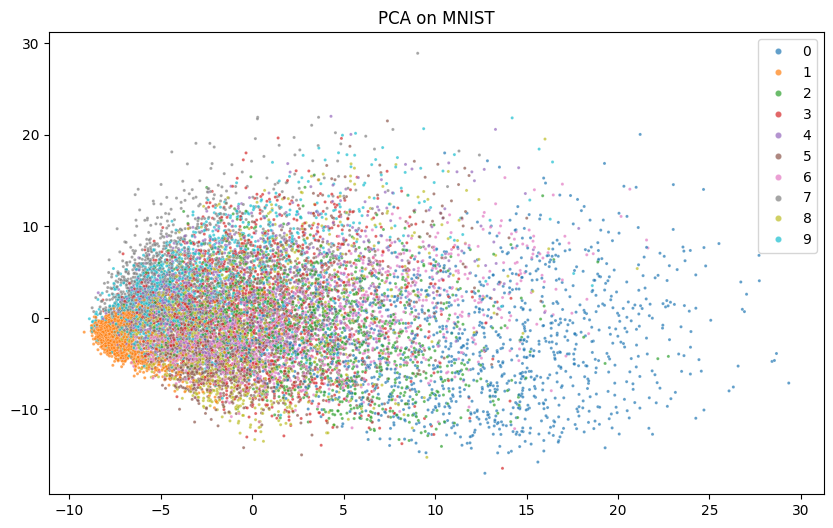

In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
plot_2D( X_pca,  y_train,  title="PCA on MNIST" ) 


## t-SNE for visualization in two-dimensions


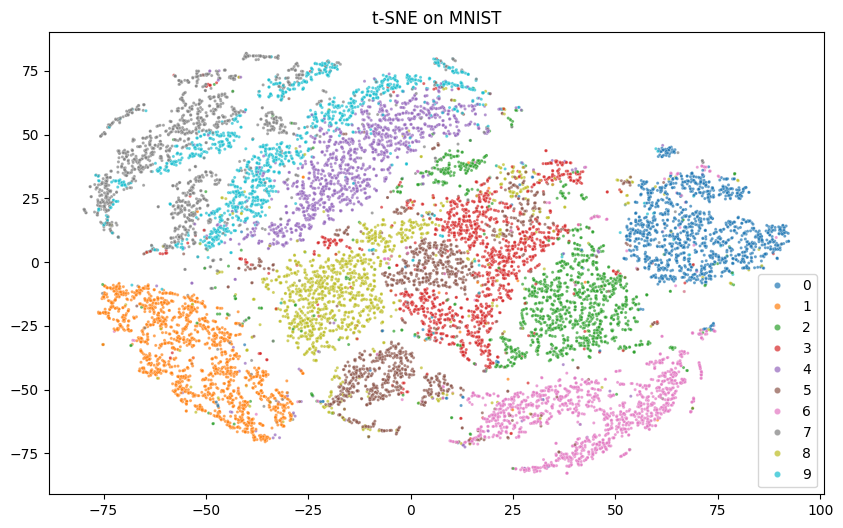

In [13]:
from  sklearn.manifold  import TSNE

tsne = TSNE( n_components=2 ,  # 
            perplexity=25,  #   how t-SNE considers local versus global aspects of the data
            learning_rate=200, #  how quickly the algorithm adjusts point positions during optimization
            random_state=42)  # 

X_tsne = tsne.fit_transform(X_train_scaled)

plot_2D(X_tsne, y_train, "t-SNE on MNIST")


## UMAP for visualization in 2-dimensions

c:\Users\USER\envs\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


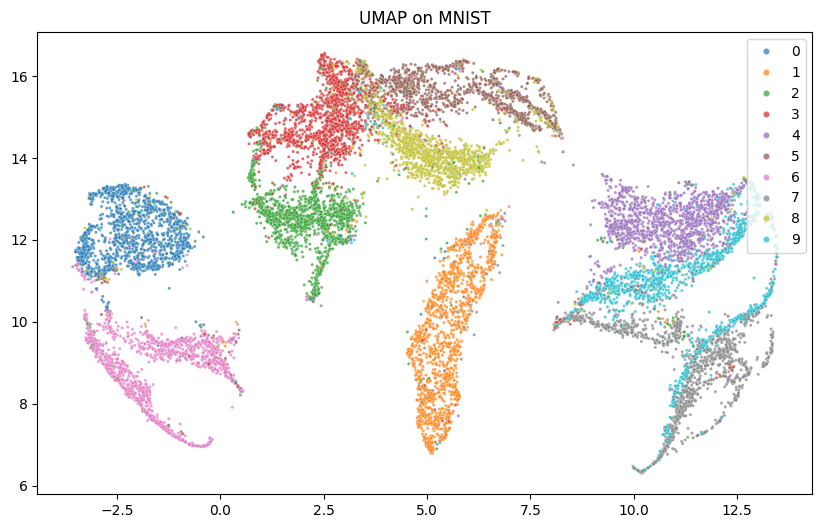

In [14]:
import umap.umap_ as umap

umap_reducer = umap.UMAP(
                            n_components=2,      
                            random_state=42, 
                            n_jobs=-1
                        )

X_umap = umap_reducer.fit_transform(X_train_scaled)

plot_2D(X_umap, y_train, "UMAP on MNIST")



## Automatically selecting optimal components


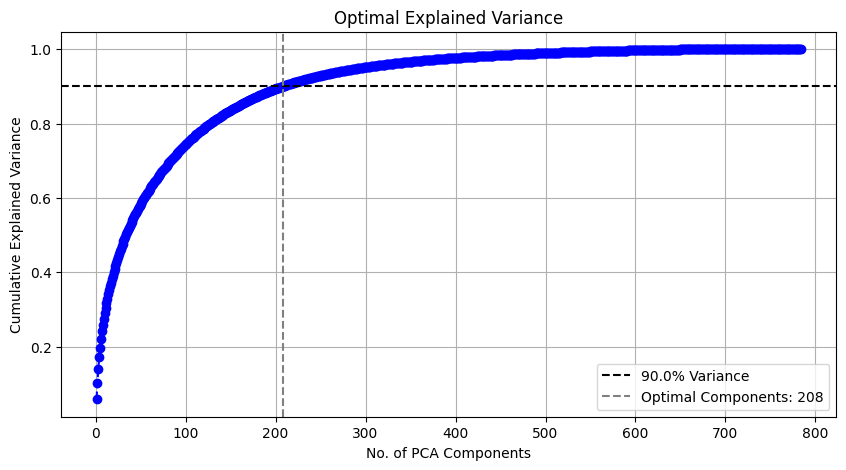

In [15]:
def get_optimal_pca(X, variance_threshold=0.95,
                    figsize=(10, 5),
                    plot=True,
                    x_lab='No. of PCA Components',
                    y_lab='Cumulative Explained Variance',
                    plot_title='Optimal Explained Variance',
                    optimal_thresh_line_color='grey',
                    variance_line_color='black',
                    linestyle='--',
                    **pca_args):


    pca = PCA(n_components=X.shape[1], **pca_args)
    pca_transformed = pca.fit_transform(X)
    

    explained_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
    
    optimal_components = np.argmax(explained_variance_ratio >= variance_threshold) + 1


    if plot:
        plt.figure(figsize=figsize)
        plt.plot(range(1, len(explained_variance_ratio) + 1),
                 explained_variance_ratio,
                 marker='o',
                 linestyle='--',
                 color='b')
        plt.axhline(y=variance_threshold,
                    color=variance_line_color,
                    linestyle=linestyle,
                    label=f"{variance_threshold * 100}% Variance")
        plt.axvline(x=optimal_components,
                    color=optimal_thresh_line_color,
                    linestyle='--',
                    label=f"Optimal Components: {optimal_components}")
        plt.xlabel(x_lab)
        plt.ylabel(y_lab)
        plt.title(plot_title)
        plt.legend()
        plt.grid()
        plt.show()

    return (optimal_components, explained_variance_ratio, pca_transformed)



(opt_comp, explained_variance_ratio, _) = get_optimal_pca(
    X_train_scaled,
    variance_threshold=0.9
)

In [16]:
pca_optim = PCA(n_components=opt_comp)
X_train_pca = pca_optim.fit_transform(X_train_scaled)
X_test_pca = pca_optim.transform(X_test_scaled)


## Train SVM classifier to predict MNIST digits


In [17]:
from sklearn.svm import SVC

svm_model = SVC(kernel="rbf", C=10, gamma=0.01)

svm_model.fit(X_train_pca, y_train)

y_pred = svm_model.predict(X_test_pca)



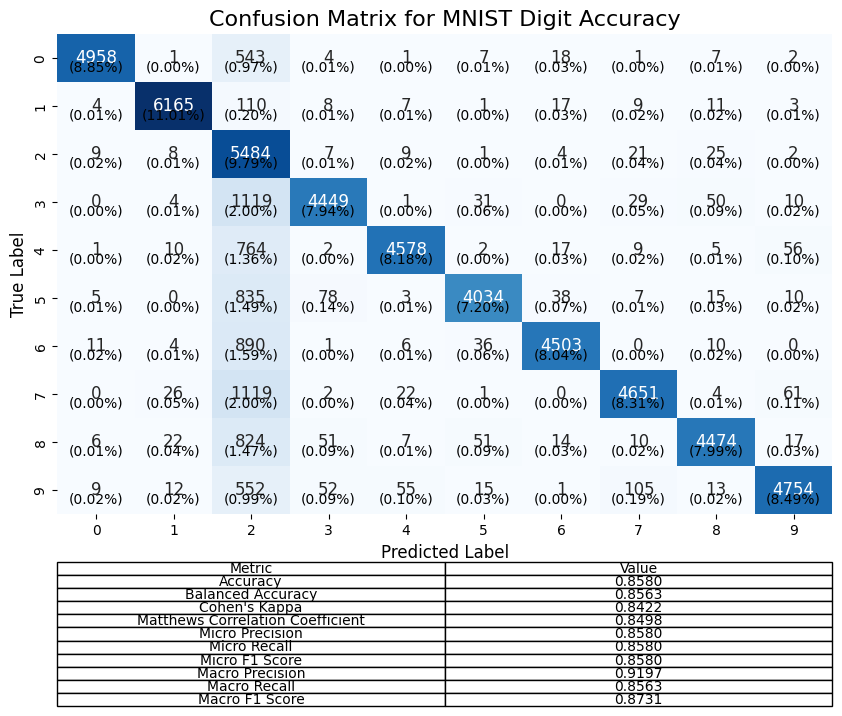

<Figure size 640x480 with 0 Axes>

In [18]:
from sklearn.metrics           import confusion_matrix
from modelviz.confusion_matrix import plot_confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

plot_confusion_matrix(
    cm=cm,
    classes=class_labels,
    model_name='MNIST Digit Accuracy',
    # label_fontsize=8,
    # annot_fontsize=8,
    # cell_fontsize=8,
    # table_fontsize=8,
    # cmap='Greys',
    # proportions_color='grey'

)
plt.tight_layout()
